<a href="https://colab.research.google.com/github/mdreduanulhoque/AI_ML_Expert_with_Phitron/blob/main/Deep_Learning/DL_Final_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [19]:
# Enter your course email here
student_email = "mdreduanulhoquesadik@gmail.com" # Example: "your.name@university.edu"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

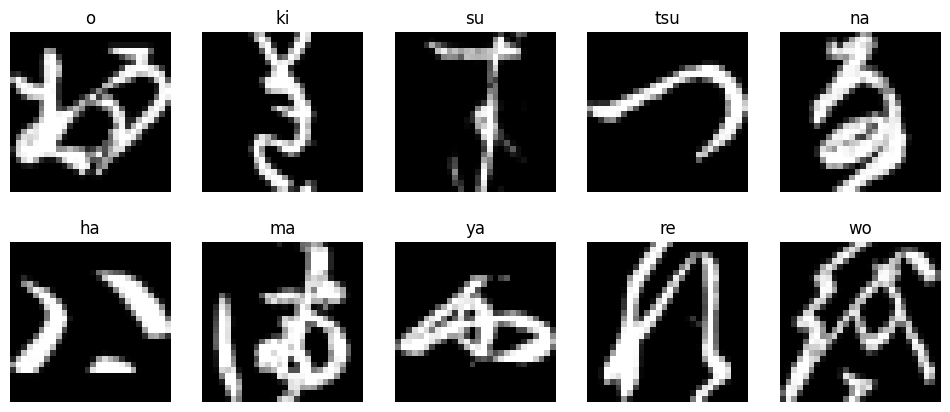

In [21]:
# YOUR CODE HERE
s_images = {}
for img , label in full_train_dataset:
  if label not in s_images:
    s_images[label] = img
  if len(s_images) == 10:
    break
fig, axes = plt.subplots(2,5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
  axes[i].imshow(s_images[i], cmap = 'gray')
  axes[i].set_title(class_names[i])
  axes[i].axis('off')

plt.show()

### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [22]:
# YOUR CODE HERE
X_full = full_train_dataset.data.numpy()
y_full = full_train_dataset.targets.numpy()

X_test_raw = test_dataset_raw.data.numpy()
y_test_raw = test_dataset_raw.targets.numpy()

X_full_scaled = X_full / 255.0
X_test_scaled = X_test_raw / 255.0

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(X_full_scaled, y_full, train_size= 50000, test_size= 10000, random_state= 42)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)

X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_test_raw, dtype= torch.long)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.long)



In [23]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [24]:
# YOUR CODE HERE
batch_size = 256

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size= batch_size, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= batch_size, shuffle= False)
test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle= False)

In [25]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [26]:
# YOUR CODE HERE
class TranslateAIClassifier(nn.Module):
  def __init__(self):
    super(TranslateAIClassifier, self).__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )
  def forward(self, x):
    return self.network(x)

model = TranslateAIClassifier()
print(model)



TranslateAIClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [27]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [28]:
# YOUR CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
epochs = 15

### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [29]:
# YOUR CODE HERE
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} ")

Epoch 1/15 | Train Loss: 0.3784 | Val Loss: 6.6151 
Epoch 2/15 | Train Loss: 0.1338 | Val Loss: 7.7375 
Epoch 3/15 | Train Loss: 0.0781 | Val Loss: 8.9063 
Epoch 4/15 | Train Loss: 0.0509 | Val Loss: 9.9978 
Epoch 5/15 | Train Loss: 0.0364 | Val Loss: 10.4308 
Epoch 6/15 | Train Loss: 0.0288 | Val Loss: 11.2431 
Epoch 7/15 | Train Loss: 0.0239 | Val Loss: 11.8350 
Epoch 8/15 | Train Loss: 0.0197 | Val Loss: 12.0765 
Epoch 9/15 | Train Loss: 0.0131 | Val Loss: 12.9500 
Epoch 10/15 | Train Loss: 0.0116 | Val Loss: 13.0532 
Epoch 11/15 | Train Loss: 0.0132 | Val Loss: 13.7279 
Epoch 12/15 | Train Loss: 0.0127 | Val Loss: 14.0293 
Epoch 13/15 | Train Loss: 0.0126 | Val Loss: 14.4645 
Epoch 14/15 | Train Loss: 0.0187 | Val Loss: 14.2610 
Epoch 15/15 | Train Loss: 0.0148 | Val Loss: 14.8641 


In [30]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (15 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [31]:
# YOUR CODE HERE
model.eval()
correct = 0
total = 0
all_preds = []

with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_preds.extend(predicted.cpu().numpy())


test_accuracy = correct / total
print(f"Test accuracy : {test_accuracy:.4f}")



Test accuracy : 0.9141


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

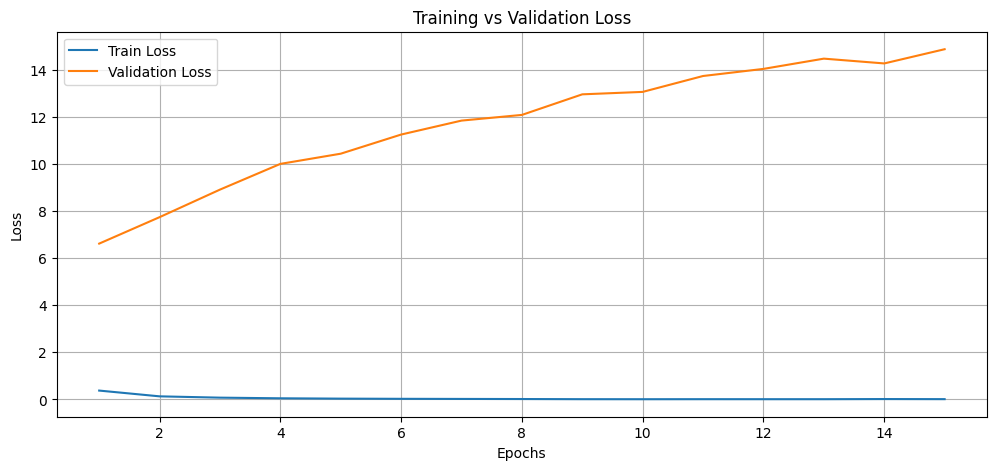

In [32]:
# YOUR CODE HERE
plt.figure(figsize=(12, 5))
plt.plot(range(1, epochs + 1), train_losses, label= "Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label= "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### 5.3 Confusion Matrix & Analysis (5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

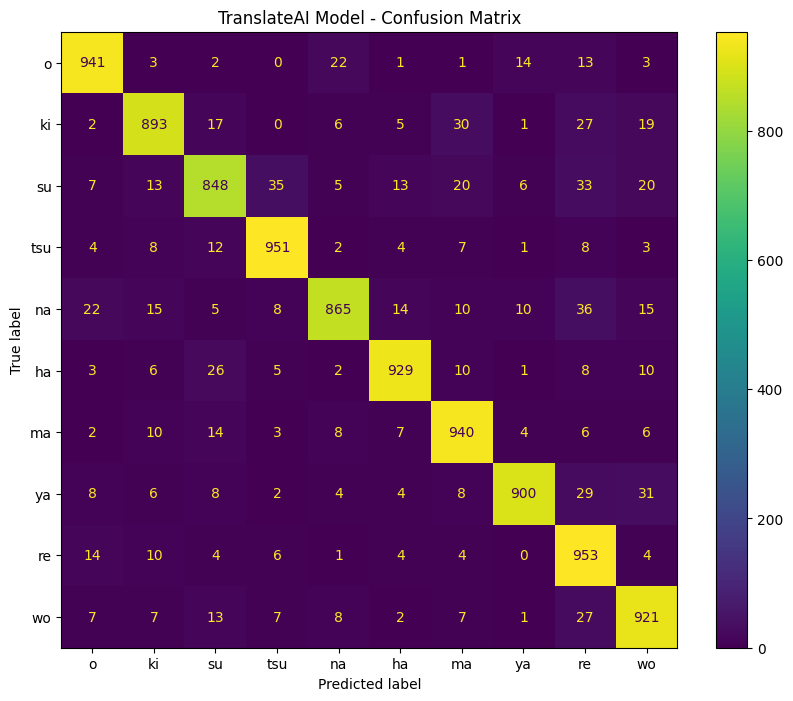

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
true_labels = y_test.numpy()

cm = confusion_matrix(true_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax)
plt.title("TranslateAI Model - Confusion Matrix")
plt.show()

*Double-click here to write your analysis*

**Your Analysis:**

